# Autocorrelación
### Econometría II
**Alejandro Mosiño** — Universidad de Guanajuato

In [ ]:
# Ejecutar solo la primera vez
# install.packages(c("tidyverse", "dynlm", "lmtest", "car", "sandwich", "orcutt"))

## Datos y modelo MCO

Usamos el índice de productividad (`Prodb`) para explicar la remuneración real por hora (`Rcompb`) en Estados Unidos, 1960-2005:

$$
\text{Rcompb}_t = \beta_1 + \beta_2 \, \text{Prodb}_t + u_t
$$

In [3]:
library(tidyverse)

datos <- read.csv("../data/E204--productivity.csv")

m1 <- lm(Rcompb ~ Prodb, data = datos)
summary(m1)


Call:
lm(formula = Rcompb ~ Prodb, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.7247 -1.9665  0.3394  2.0095  3.9586 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 32.74190    1.39402   23.49   <2e-16 ***
Prodb        0.67041    0.01567   42.78   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.384 on 44 degrees of freedom
Multiple R-squared:  0.9765,	Adjusted R-squared:  0.976 
F-statistic:  1830 on 1 and 44 DF,  p-value: < 2.2e-16


In [4]:
datos$e <- residuals(m1)
datos <- ts(datos, start = c(1960), frequency = 1)

## Detección gráfica

Graficamos los residuales contra el tiempo: la presencia de rachas o ciclos sugiere autocorrelación.

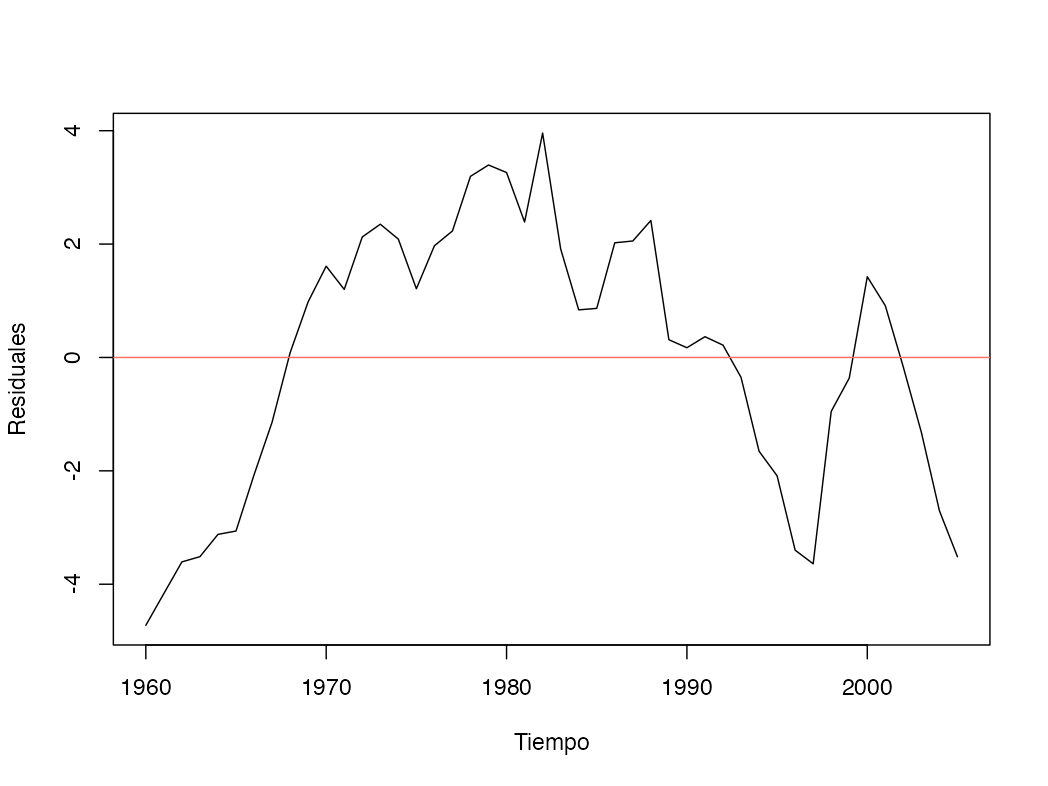

In [5]:
plot(datos[, "e"], ylab = "Residuales", xlab = "Tiempo")
abline(h = 0, col = "#ff6f61")

## El correlograma: FAC y FACP

La función de autocorrelación (FAC) mide la correlación entre $e_t$ y sus propios rezagos:

$$
\hat{r}_k = \frac{\sum_{t=1}^{T-k} (e_t - \bar{e})(e_{t+k} - \bar{e})}{\sum_{t=1}^T (e_t - \bar{e})^2}
$$

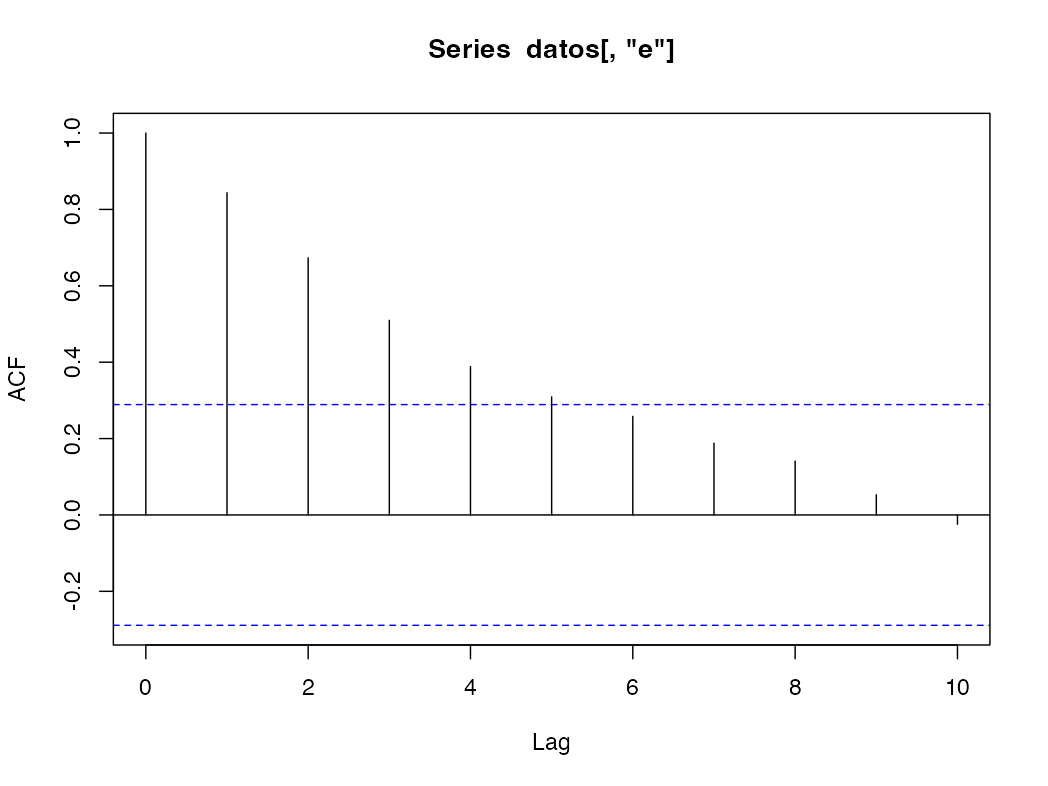

In [6]:
acf(datos[, "e"], lag.max = 10, ci = 0.95)

La función de autocorrelación parcial (FACP) es útil para identificar el orden del proceso autorregresivo de los errores.

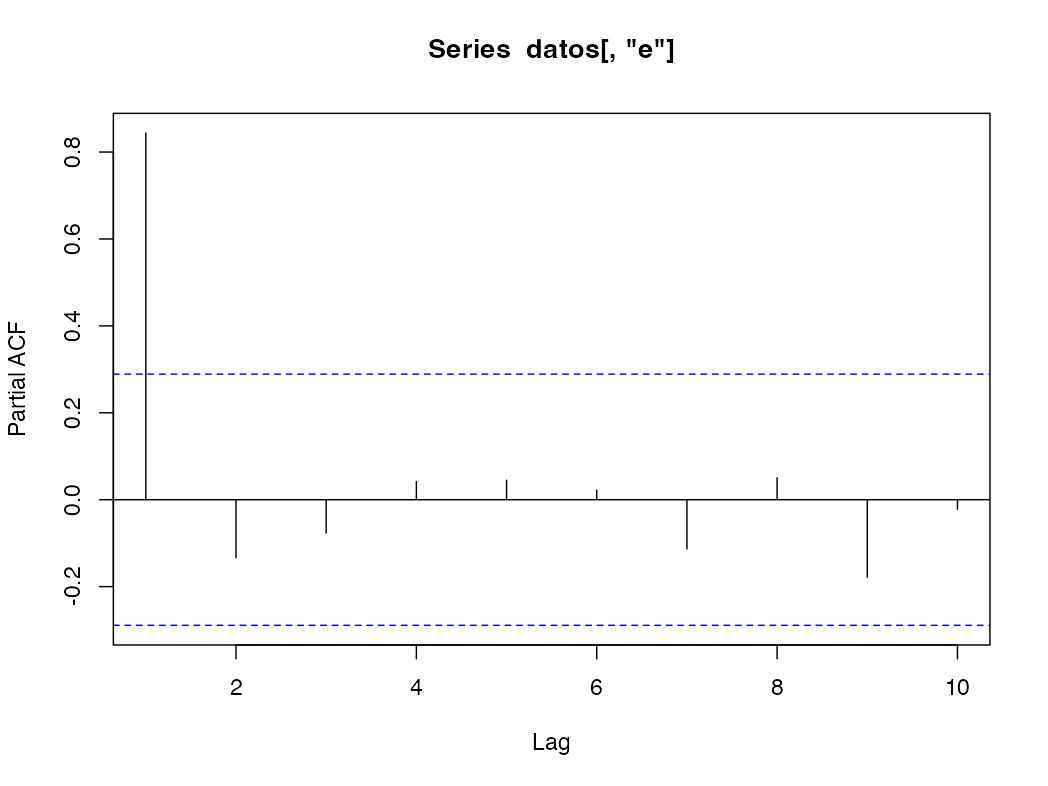

In [7]:
pacf(datos[, "e"], lag.max = 10, ci = 0.95)

## Prueba de Ljung-Box

$$
H_0: \text{no hay autocorrelación de orden } k \qquad H_1: \text{sí la hay}
$$

Paso a paso: el estadístico $Q$ se construye a partir de la FAC estimada.

$$
Q = T(T+2) \sum_{j=1}^k \frac{\hat{r}_j^2}{T-j}
$$

In [8]:
fac <- acf(datos[, "e"], lag.max = 2, plot = FALSE)$acf[-1]
Tn <- nobs(m1)

Q <- Tn * (Tn + 2) * sum(fac^2 / (Tn - seq_along(fac)))
pchisq(Q, df = 2, lower.tail = FALSE)

[1] 2.979559e-13

Con la función `Box.test`:

In [9]:
Box.test(datos[, "e"], lag = 2, type = "Ljung-Box")


	Box-Ljung test

data:  datos[, "e"]
X-squared = 57.684, df = 2, p-value = 2.98e-13


## Prueba de Breusch-Godfrey

$$
H_0: \mathbb{E}(u_t u_\tau) = 0 \ \forall t \neq \tau \qquad H_1: \mathbb{E}(u_t u_\tau) \neq 0 \ \text{para algún } t \neq \tau
$$

Paso a paso: regresamos $e_t$ sobre las variables explicativas y su propio rezago, y calculamos $BG = T R^2$.

In [10]:
e_l1 <- c(NA, head(datos[, "e"], -1))

aux_bg <- lm(e ~ Prodb + e_l1, data = datos)
BG <- nobs(aux_bg) * summary(aux_bg)$r.squared
pchisq(BG, df = 1, lower.tail = FALSE)

[1] 7.666974e-10

Con la librería `lmtest`:

In [11]:
library(lmtest)
bgtest(m1, order = 1)

Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




	Breusch-Godfrey test for serial correlation of order up to 1

data:  m1
LM test = 34.618, df = 1, p-value = 4.012e-09


## Prueba de Durbin-Watson

$$
H_0: \rho = 0 \qquad H_1: \rho \neq 0
$$

Paso a paso: el estadístico $DW$ compara la variación de los residuales entre periodos consecutivos con su varianza total.

$$
DW = \frac{\sum_{t=2}^T (e_t - e_{t-1})^2}{\sum_{t=1}^T e_t^2}
$$

In [12]:
e <- datos[, "e"]
DW <- sum(diff(e)^2) / sum(e^2)
DW

[1] 0.1738878

Con la librería `lmtest`:

In [13]:
dwtest(m1)


	Durbin-Watson test

data:  m1
DW = 0.17389, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


## Corrección: MCGF por Cochrane-Orcutt, AR(1)

Suponemos que los errores siguen un proceso $AR(1)$: $u_t = \rho u_{t-1} + \varepsilon_t$. Estimamos $\rho$ y **transformamos** cada variable (incluida la constante) como $\tilde{z}_t = z_t - \rho z_{t-1}$.

In [19]:
library(dynlm)

aux_co <- dynlm(e ~ L(e, 1) - 1, data = datos)
r <- coef(aux_co)

datos_co <- datos - r * stats::lag(datos, -1)
colnames(datos_co)[2] <- "Rcompb"
colnames(datos_co)[3] <- "Prodb"

m2 <- lm(Rcompb ~ Prodb, data = datos_co)
summary(m2)
dwtest(m2)


	Durbin-Watson test

data:  m2
DW = 1.6395, p-value = 0.08453
alternative hypothesis: true autocorrelation is greater than 0


## Corrección: MCGF por Cochrane-Orcutt, AR(2)

Si suponemos que los errores siguen un proceso $AR(2)$: $u_t = \rho_1 u_{t-1} + \rho_2 u_{t-2} + \varepsilon_t$, la transformación es $\tilde{z}_t = z_t - \rho_1 z_{t-1} - \rho_2 z_{t-2}$.

In [21]:
aux_co2 <- dynlm(e ~ L(e, 1) + L(e, 2) - 1, data = datos)
r1 <- coef(aux_co2)[1]
r2 <- coef(aux_co2)[2]

datos_co2 <- datos - r1 * stats::lag(datos, -1) - r2 * stats::lag(datos, -2)
colnames(datos_co2)[2] <- "Rcompb"
colnames(datos_co2)[3] <- "Prodb"

m3 <- lm(Rcompb ~ Prodb, data = datos_co2)
summary(m3)
dwtest(m3)


	Durbin-Watson test

data:  m3
DW = 2.1945, p-value = 0.6958
alternative hypothesis: true autocorrelation is greater than 0


## Corrección: errores estándar robustos de Newey-West

In [22]:
library(sandwich)
coeftest(m1, vcov = NeweyWest(m1))


t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)
(Intercept) 32.74190   58.11714  0.5634   0.5760
Prodb        0.67041    0.72836  0.9204   0.3624
